In [1]:
import sys
sys.path.append("../../src")

import numpy as np
from scipy.stats import ortho_group
import matplotlib.pyplot as plt
from IPython import display
import pylab as pl

from CorInfoMaxBSS import OnlineCorInfoMax2by2
from visualization_utils import display_matrix, subplot_1D_signals
from bss_utils import generate_uncorrelated_uniform_sources, addWGN

# Generate Sources and Mix Them (2 by 2 case)

In [2]:
np.random.seed(0)
N = 100000
NumberofSources = 2
NumberofMixtures = 2

S = generate_uncorrelated_uniform_sources(NumberofSources, N)
print("The following is the correlation matrix of sources")
display_matrix(np.corrcoef(S))

# Generate Mxr random mixing from i.i.d N(0,1)
A = np.random.randn(NumberofMixtures, NumberofSources) # Random Gaussian mixing matrix
# A = ortho_group.rvs(dim=2) # Random orthogonal mixing matrix
X_noNoise = np.dot(A, S)

SNR = 30
X = addWGN(X_noNoise, SNR)

SNRinp = 10 * np.log10(
    np.sum(np.mean(X_noNoise ** 2, axis=1))
    / np.sum(np.mean((X_noNoise - X)**2, axis=1))
)
print("The following is the mixture matrix A")
display_matrix(A)
print("Input SNR is : {}".format(SNRinp))

The following is the correlation matrix of sources


<IPython.core.display.Math object>

The following is the mixture matrix A


<IPython.core.display.Math object>

Input SNR is : 29.999477189211355


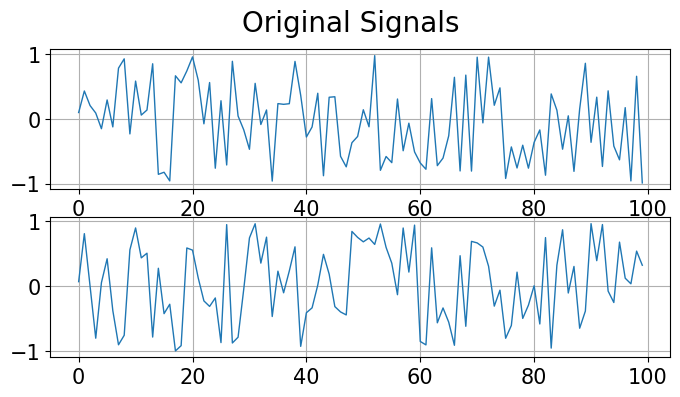

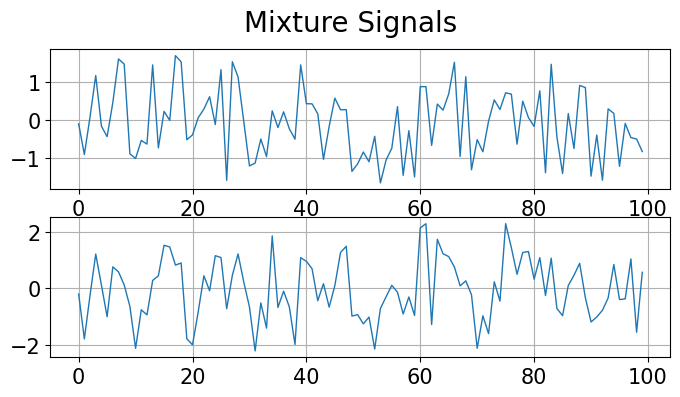

In [3]:
subplot_1D_signals(
    S[:, 0:100], title="Original Signals", figsize=(8, 4), colorcode=None
)
subplot_1D_signals(
    X[:, 0:100], title="Mixture Signals", figsize=(8, 4), colorcode=None
)

In [4]:
lambday = 1 - 1e-1 / 10
lambdae = 1 - 1e-1 / 10
# Inverse output covariance
By = 1. * np.eye(2)
epsilon = 1e-3
update_off_diagonal_By = False

debug_iteration_point = 25000
model = OnlineCorInfoMax2by2(
    muW=30 * 1e-3,
    lambday=lambday,
    lambdae=lambdae,
    By=By,
    epsilon = epsilon,
    neural_OUTPUT_COMP_TOL=1e-6,
    update_off_diagonal_By = update_off_diagonal_By,
    ## The below arguments are used only for debugging
    set_ground_truth=True,
    S=S,
    A=A,
)

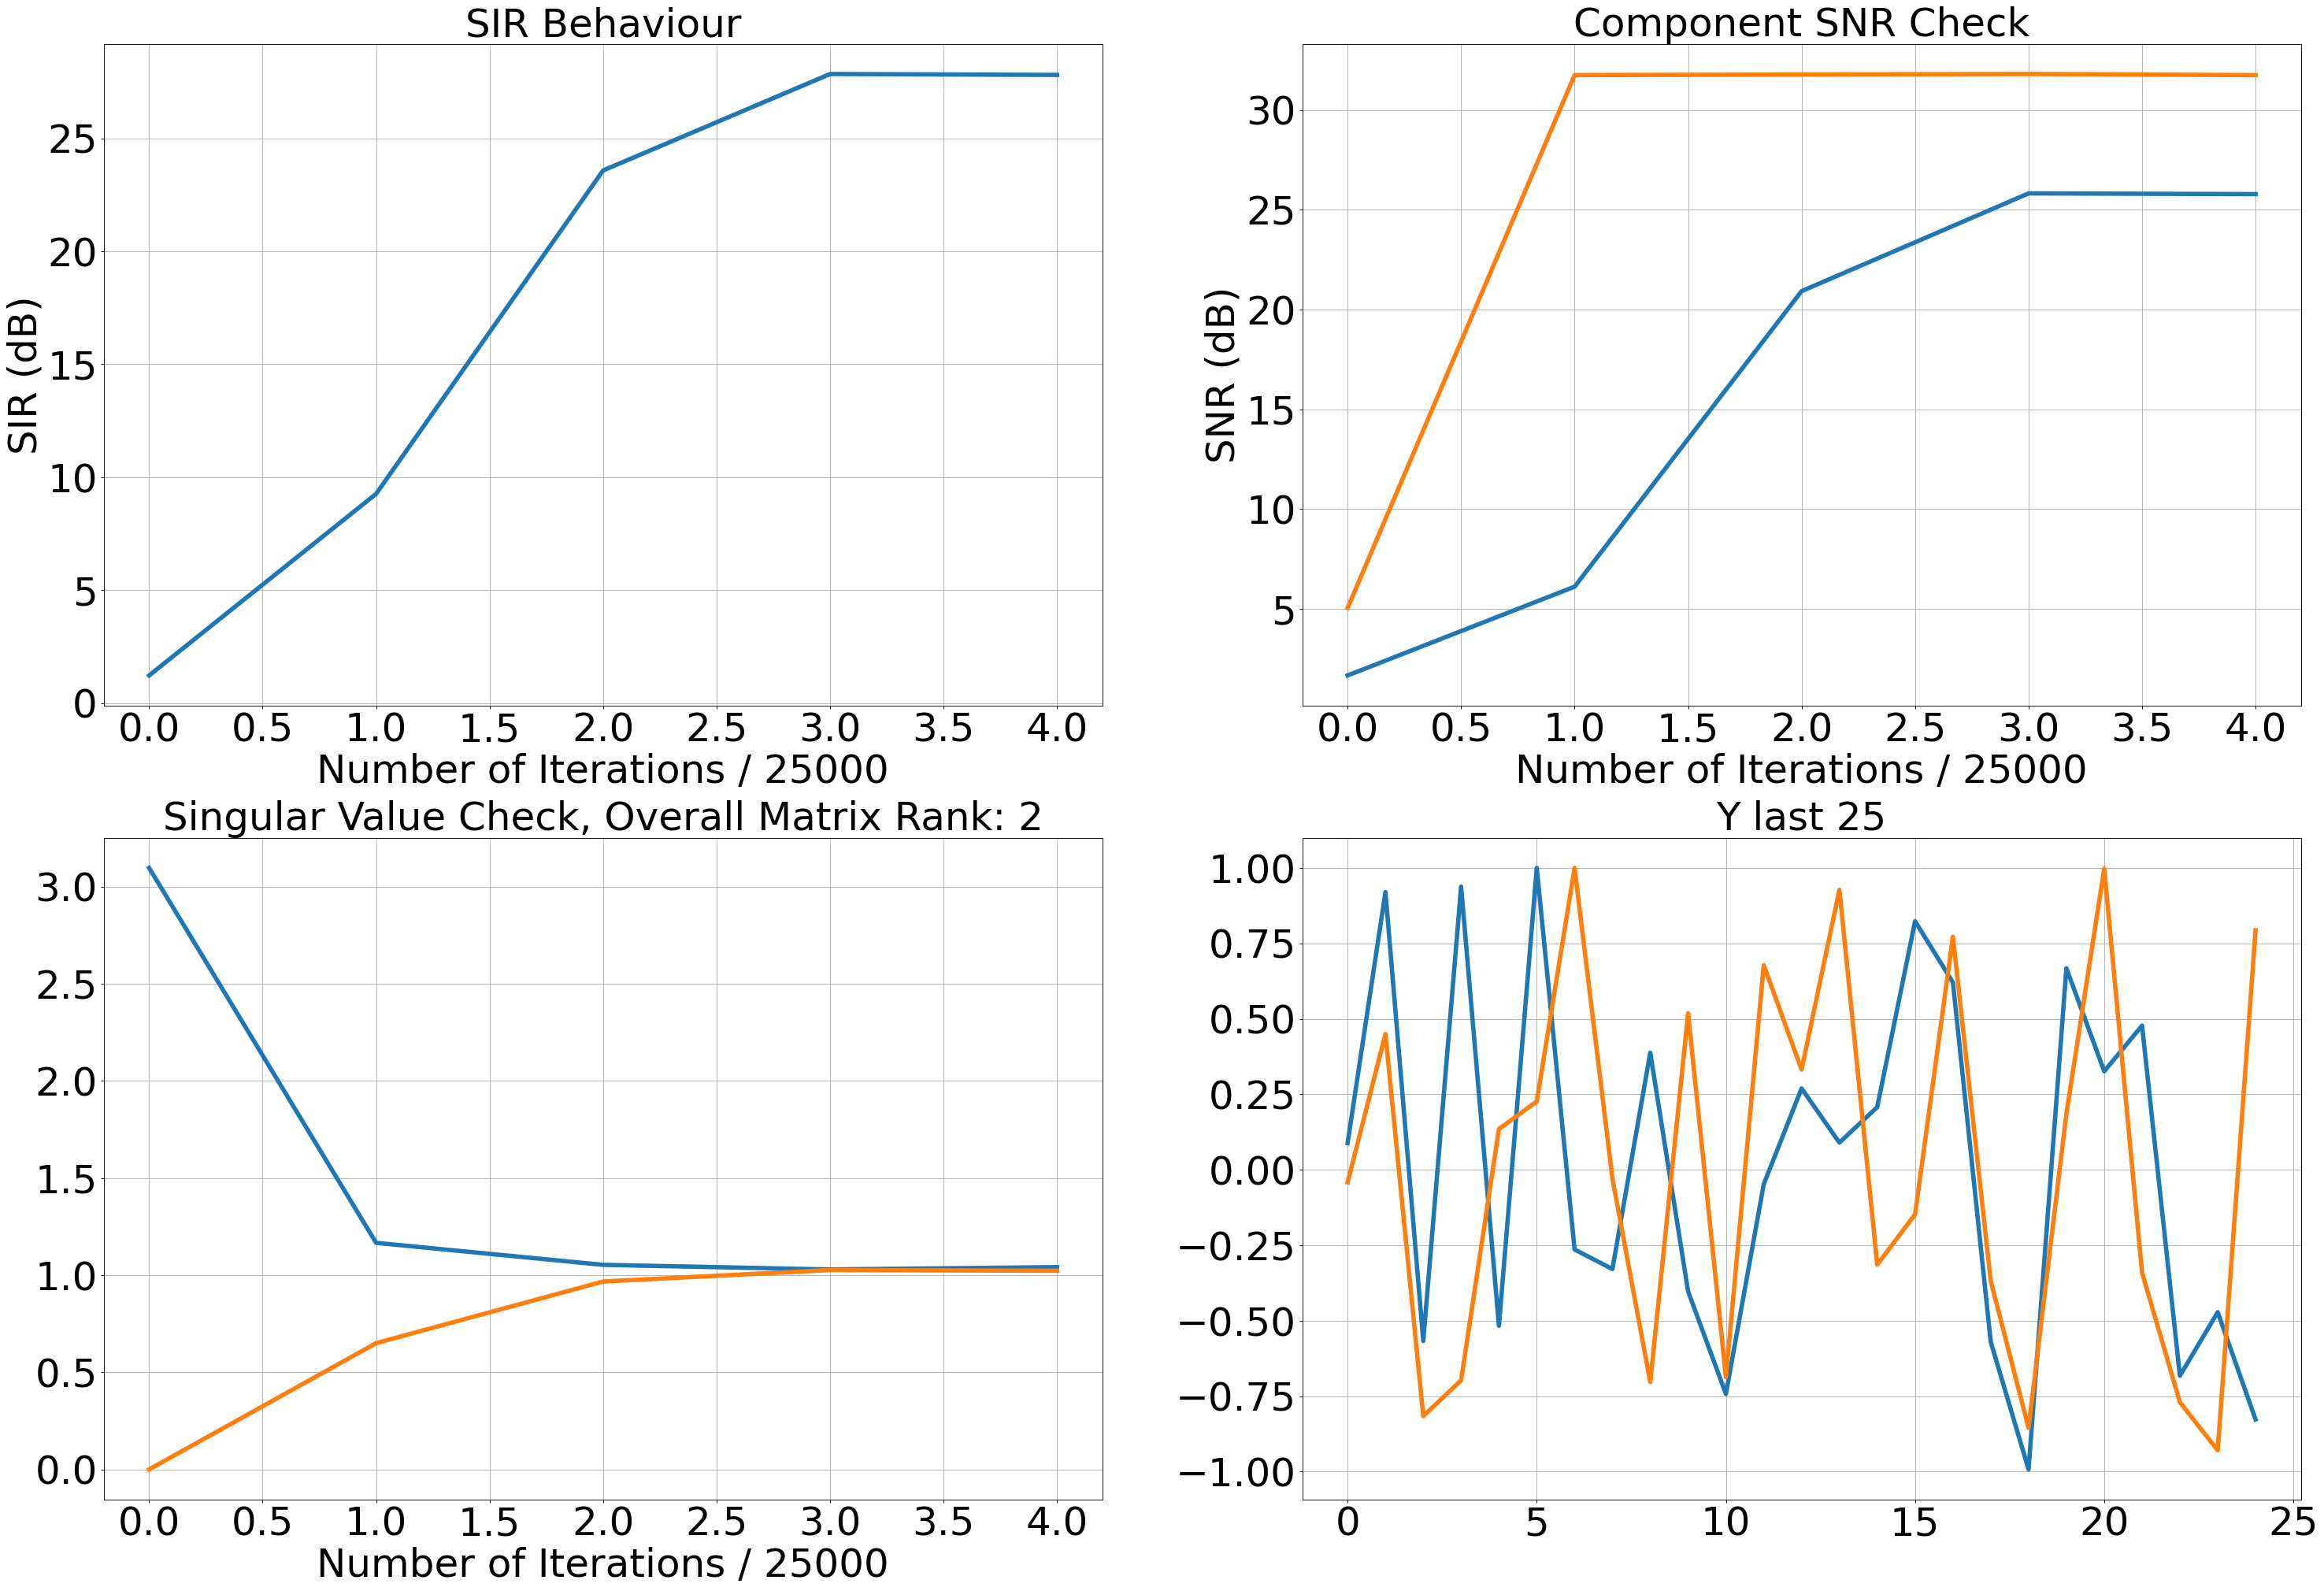

100%|██████████| 100000/100000 [00:16<00:00, 6066.06it/s]


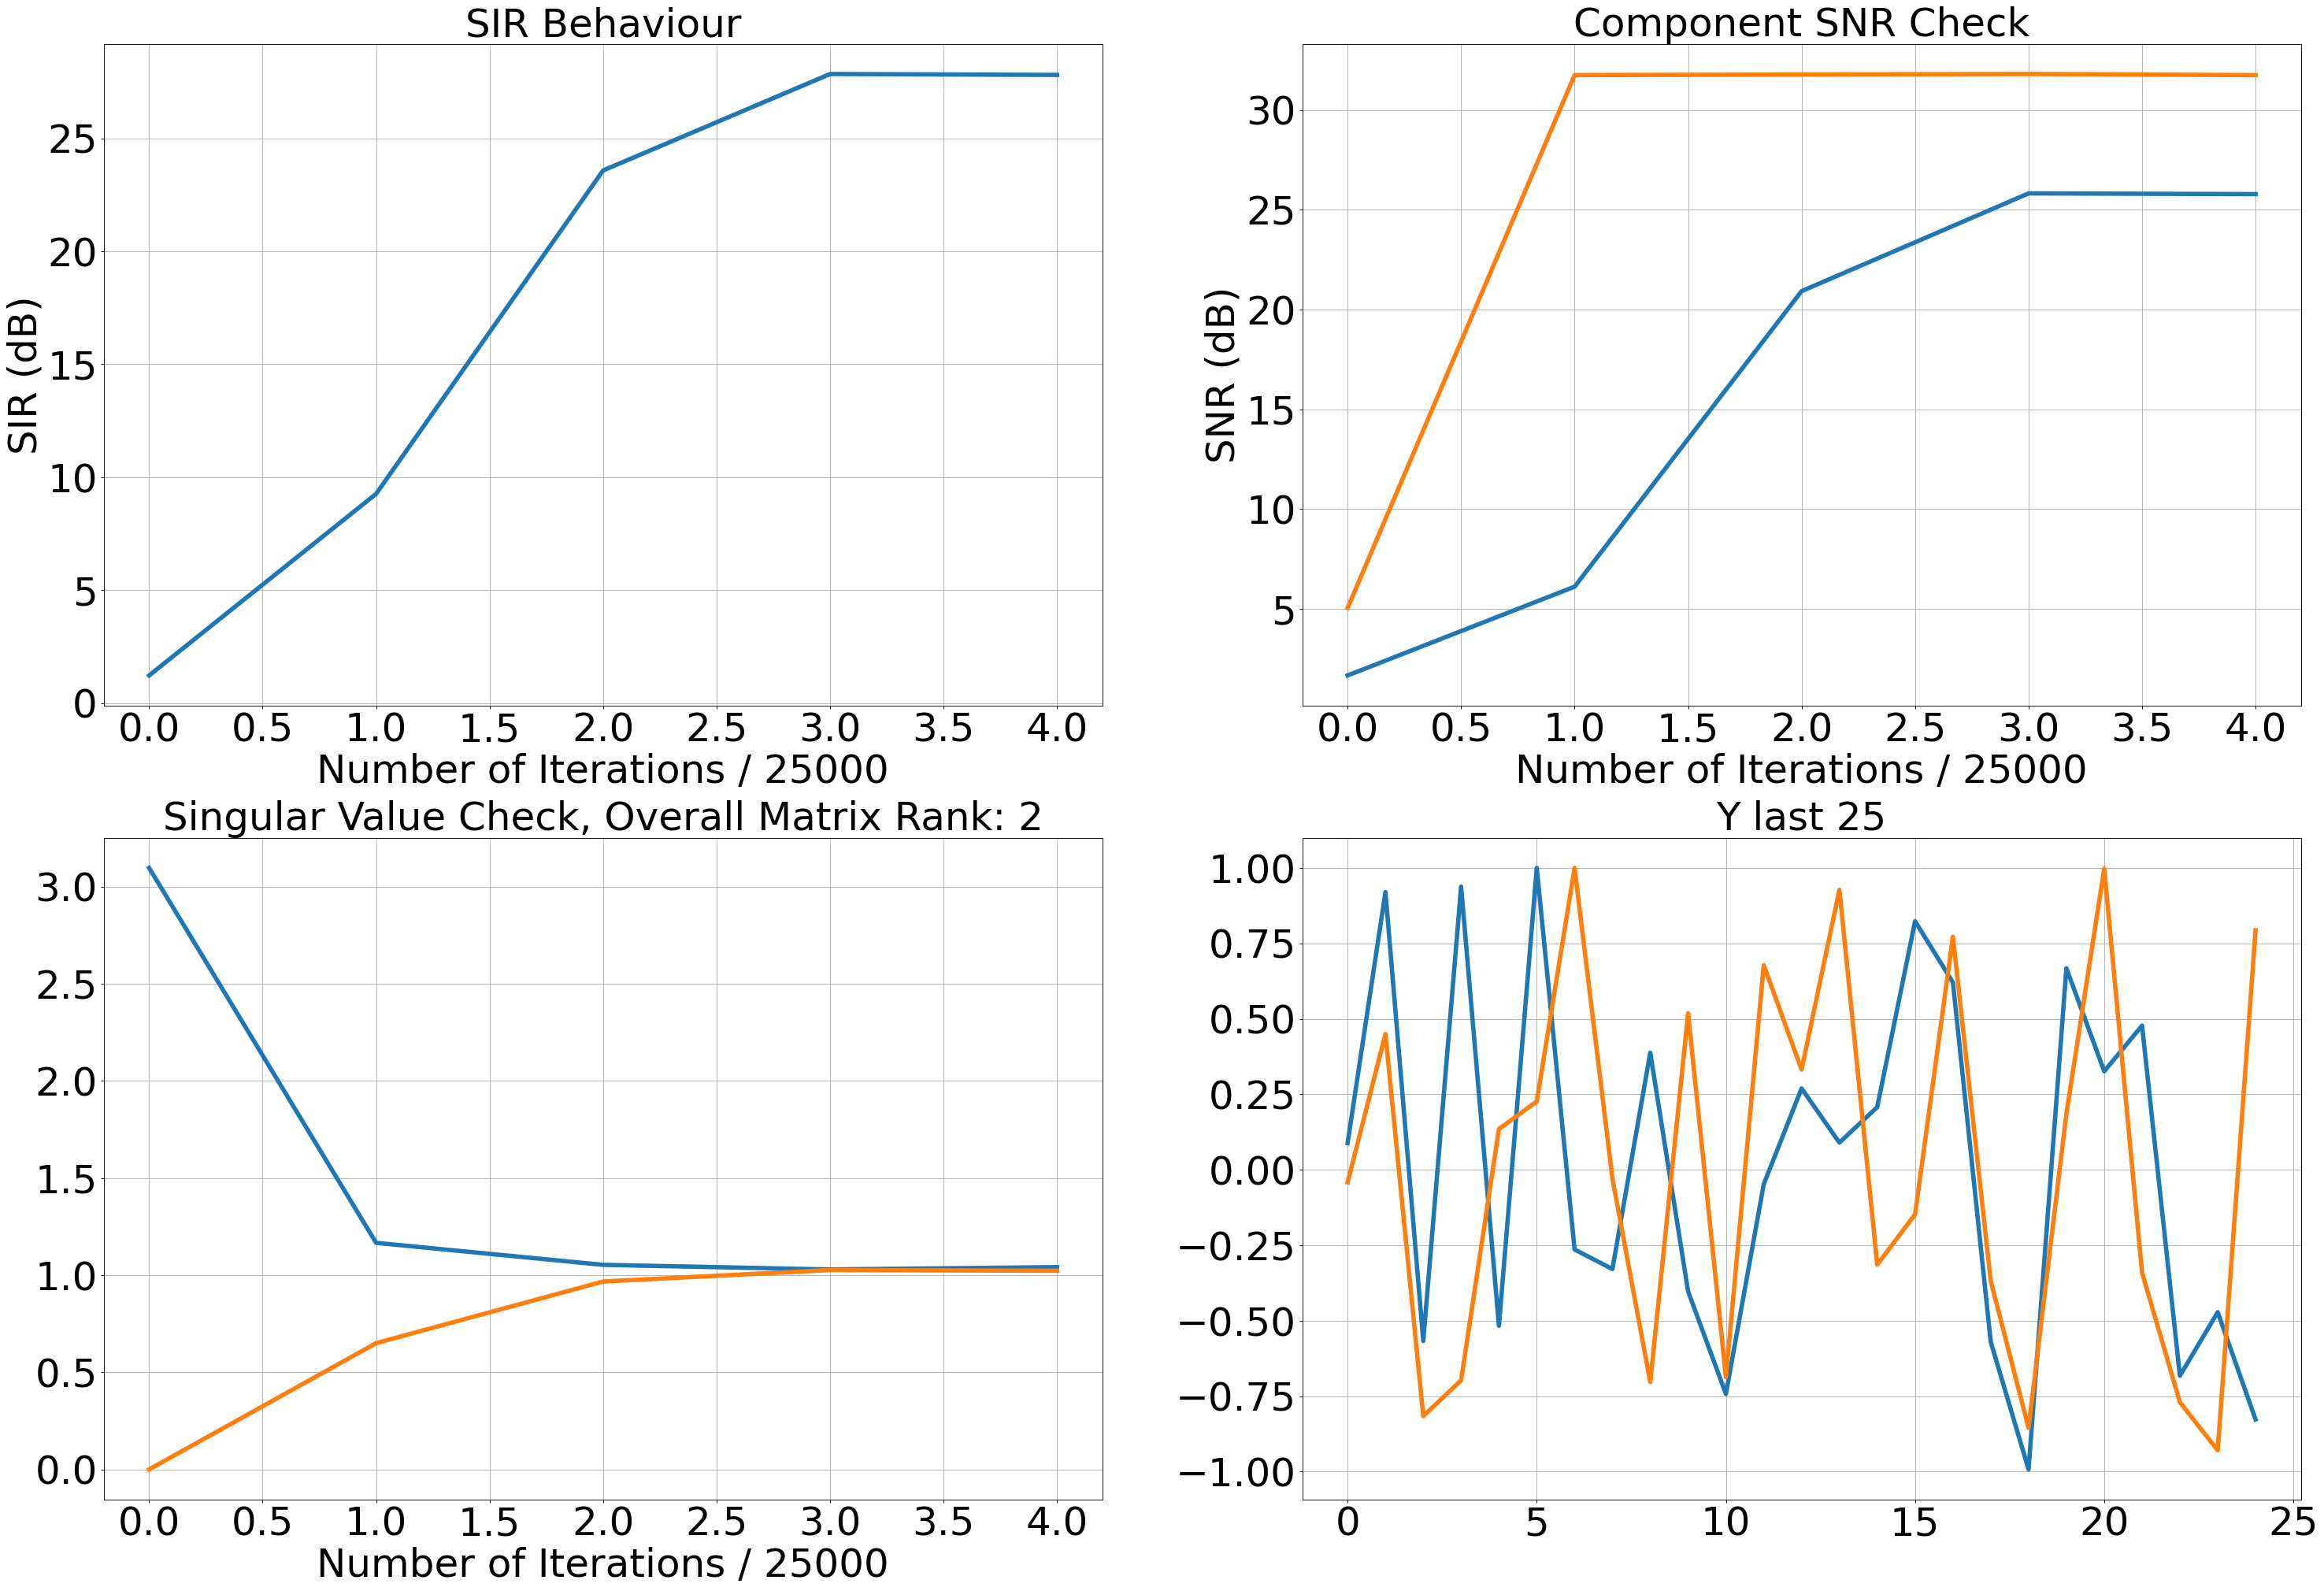

In [5]:
model.fit_batch_antisparse(
    X=X,
    n_epochs=1,
    neural_dynamic_iterations=500,
    plot_in_jupyter=True,
    neural_lr_start=0.9,
    neural_lr_stop=0.001,
    debug_iteration_point=debug_iteration_point,
    shuffle=True,
)

In [6]:
Wf = model.compute_overall_mapping(return_mapping=True)
Y = Wf @ X
Y_ = model.signed_and_permutation_corrected_sources(S, Y)
coef_ = ((Y_ * S).sum(axis=1) / (Y_ * Y_).sum(axis=1)).reshape(-1, 1)
Y_ = coef_ * Y_

print("Component SNR Values : {}\n".format(model.snr_jit(S, Y_)))

SINR = 10 * np.log10(model.CalculateSINRjit(Y_, S)[0])

print("Overall SINR : {}".format(SINR))

Component SNR Values : [25.78542658 31.7505246 ]

Overall SINR : 27.807967472893868


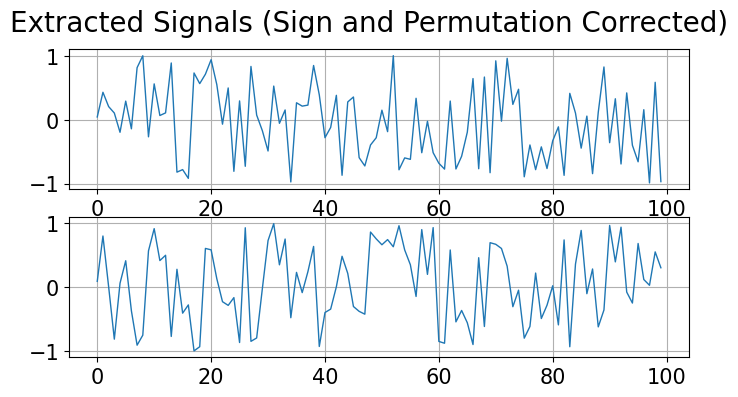

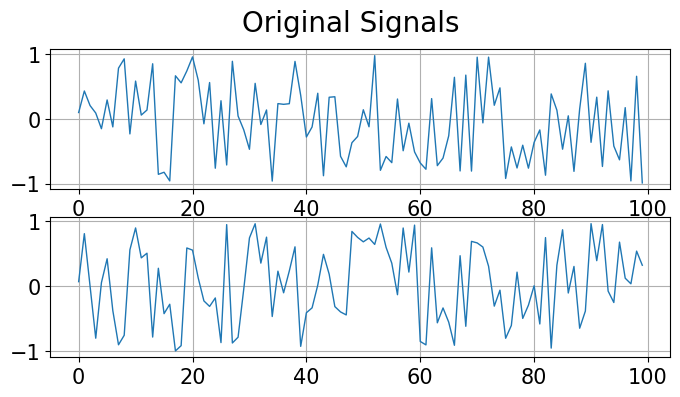

In [7]:
subplot_1D_signals(
    Y_[:, 0:100],
    title="Extracted Signals (Sign and Permutation Corrected)",
    figsize=(8, 4),
    colorcode=None,
)
subplot_1D_signals(
    S[:, 0:100], title="Original Signals", figsize=(8, 4), colorcode=None
)

In [8]:
model.By

array([[2.68324675, 0.        ],
       [0.        , 2.97575533]])